In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset successfully loaded!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset successfully loaded!
Dataset shape: (23486, 11)


,no,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [2]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['no', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   no                       23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory

In [3]:
initial_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Unique_Values": df.nunique(dropna=True).values,
    "Missing_Values": df.isnull().sum().values,
    "Missing_Percentage": (
        df.isnull().mean().mul(100).round(2).values
    )
})

display(initial_summary)

,Column,Data_Type,Unique_Values,Missing_Values,Missing_Percentage
0,no,int64,23486,0,0.00
1,Clothing ID,int64,1206,0,0.00
2,Age,int64,77,0,0.00
3,Title,str,13993,3810,16.22
4,Review Text,str,22634,845,3.60
5,Rating,int64,5,0,0.00
6,Recommended IND,int64,2,0,0.00
7,Positive Feedback Count,int64,82,0,0.00
8,Division Name,str,3,14,0.06
9,Department Name,str,6,14,0.06


In [4]:
df_work = df.copy()

index_columns = ["no"]

numerical_columns = [
    "Age",
    "Positive Feedback Count"
]

categorical_columns = [
    "Division Name",
    "Department Name",
    "Class Name",
    "Rating",
    "Recommended IND"
]

high_cardinality_columns = [
    "Clothing ID"
]

text_columns = [
    "Title",
    "Review Text"
]

print("Index columns:", index_columns)
print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)
print("High-cardinality columns:", high_cardinality_columns)
print("Text columns:", text_columns)

Index columns: ['no']
Numerical columns: ['Age', 'Positive Feedback Count']
Categorical columns: ['Division Name', 'Department Name', 'Class Name', 'Rating', 'Recommended IND']
High-cardinality columns: ['Clothing ID']
Text columns: ['Title', 'Review Text']


In [5]:
analysis_columns = categorical_columns + high_cardinality_columns

df_cat = df_work[analysis_columns].copy()

print("Selected categorical dataset shape:", df_cat.shape)
display(df_cat.head())

Selected categorical dataset shape: (23486, 6)


,Division Name,Department Name,Class Name,Rating,Recommended IND,Clothing ID
0,Initmates,Intimate,Intimates,4,1,767
1,General,Dresses,Dresses,5,1,1080
2,General,Dresses,Dresses,3,0,1077
3,General Petite,Bottoms,Pants,5,1,1049
4,General,Tops,Blouses,5,1,847


In [6]:
def classify_cardinality(data, columns):
    cardinality_records = []

    for column in columns:
        unique_count = data[column].nunique(dropna=True)
        total_count = data[column].notna().sum()

        cardinality_ratio = (
            unique_count / total_count
            if total_count > 0 else 0
        )

        if unique_count <= 10:
            level = "Low Cardinality"
        elif unique_count <= 50:
            level = "Medium Cardinality"
        else:
            level = "High Cardinality"

        cardinality_records.append({
            "Column": column,
            "Unique_Categories": unique_count,
            "Non_Missing_Values": total_count,
            "Cardinality_Ratio": round(cardinality_ratio, 4),
            "Cardinality_Level": level
        })

    return pd.DataFrame(cardinality_records)

cardinality_summary = classify_cardinality(
    df_cat,
    analysis_columns
)

display(cardinality_summary)

,Column,Unique_Categories,Non_Missing_Values,Cardinality_Ratio,Cardinality_Level
0,Division Name,3,23472,0.0001,Low Cardinality
1,Department Name,6,23472,0.0003,Low Cardinality
2,Class Name,20,23472,0.0009,Medium Cardinality
3,Rating,5,23486,0.0002,Low Cardinality
4,Recommended IND,2,23486,0.0001,Low Cardinality
5,Clothing ID,1206,23486,0.0513,High Cardinality


In [7]:
df_cat_clean = df_cat.copy()

missing_before = df_cat_clean.isnull().sum().to_frame(
    name="Missing_Before"
)

display(missing_before)

,Missing_Before
Division Name,14
Department Name,14
Class Name,14
Rating,0
Recommended IND,0
Clothing ID,0


In [8]:
category_text_columns = [
    "Division Name",
    "Department Name",
    "Class Name"
]

for column in category_text_columns:
    df_cat_clean[column] = (
        df_cat_clean[column]
        .astype("string")
        .str.strip()
        .fillna("Unknown")
    )

print("Categorical values successfully cleaned.")
display(df_cat_clean.head())

Categorical values successfully cleaned.


,Division Name,Department Name,Class Name,Rating,Recommended IND,Clothing ID
0,Initmates,Intimate,Intimates,4,1,767
1,General,Dresses,Dresses,5,1,1080
2,General,Dresses,Dresses,3,0,1077
3,General Petite,Bottoms,Pants,5,1,1049
4,General,Tops,Blouses,5,1,847


In [9]:
missing_after = df_cat_clean.isnull().sum().to_frame(
    name="Missing_After"
)

missing_comparison = missing_before.join(missing_after)

display(missing_comparison)

print(
    "\nTotal missing values after cleaning:",
    df_cat_clean.isnull().sum().sum()
)

,Missing_Before,Missing_After
Division Name,14,0
Department Name,14,0
Class Name,14,0
Rating,0,0
Recommended IND,0,0
Clothing ID,0,0



Total missing values after cleaning: 0


In [10]:
for column in category_text_columns:
    print(f"\nColumn: {column}")
    print(df_cat_clean[column].value_counts(dropna=False))


Column: Division Name
Division Name
General           13850
General Petite     8120
Initmates          1502
Unknown              14
Name: count, dtype: int64[pyarrow]

Column: Department Name
Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
Unknown        14
Name: count, dtype: int64[pyarrow]

Column: Class Name
Class Name
Dresses           6319
Knits             4843
Blouses           3097
Sweaters          1428
Pants             1388
Jeans             1147
Fine gauge        1100
Skirts             945
Jackets            704
Lounge             691
Swim               350
Outerwear          328
Shorts             317
Sleep              228
Legwear            165
Intimates          154
Layering           146
Trend              119
Unknown             14
Casual bottoms       2
Chemises             1
Name: count, dtype: int64[pyarrow]


In [11]:
def categorical_frequency(data, column):
    frequency = (
        data[column]
        .value_counts(dropna=False)
        .rename_axis("Category")
        .reset_index(name="Frequency")
    )

    frequency["Percentage"] = (
        frequency["Frequency"] / len(data) * 100
    ).round(2)

    frequency["Cumulative_Percentage"] = (
        frequency["Percentage"].cumsum()
    ).round(2)

    frequency.insert(
        0,
        "Column",
        column
    )

    return frequency

division_frequency = categorical_frequency(
    df_cat_clean,
    "Division Name"
)

display(division_frequency)

,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Division Name,General,13850,58.97,58.97
1,Division Name,General Petite,8120,34.57,93.54
2,Division Name,Initmates,1502,6.4,99.94
3,Division Name,Unknown,14,0.06,100.0


In [12]:
frequency_tables = {}

for column in analysis_columns:
    frequency_tables[column] = categorical_frequency(
        df_cat_clean,
        column
    )

print("Frequency tables successfully created!")
print("Available tables:", list(frequency_tables.keys()))

Frequency tables successfully created!
Available tables: ['Division Name', 'Department Name', 'Class Name', 'Rating', 'Recommended IND', 'Clothing ID']


In [13]:
frequency_tables["Department Name"]

,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Department Name,Tops,10468,44.57,44.57
1,Department Name,Dresses,6319,26.91,71.48
2,Department Name,Bottoms,3799,16.18,87.66
3,Department Name,Intimate,1735,7.39,95.05
4,Department Name,Jackets,1032,4.39,99.44
5,Department Name,Trend,119,0.51,99.95
6,Department Name,Unknown,14,0.06,100.01


In [14]:
regular_frequency_columns = [
    "Division Name",
    "Department Name",
    "Class Name",
    "Rating",
    "Recommended IND"
]

for column in regular_frequency_columns:
    print("\n" + "=" * 60)
    print(f"Frequency Distribution: {column}")
    print("=" * 60)

    display(frequency_tables[column])


Frequency Distribution: Division Name


,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Division Name,General,13850,58.97,58.97
1,Division Name,General Petite,8120,34.57,93.54
2,Division Name,Initmates,1502,6.4,99.94
3,Division Name,Unknown,14,0.06,100.0



Frequency Distribution: Department Name


,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Department Name,Tops,10468,44.57,44.57
1,Department Name,Dresses,6319,26.91,71.48
2,Department Name,Bottoms,3799,16.18,87.66
3,Department Name,Intimate,1735,7.39,95.05
4,Department Name,Jackets,1032,4.39,99.44
5,Department Name,Trend,119,0.51,99.95
6,Department Name,Unknown,14,0.06,100.01



Frequency Distribution: Class Name


,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Class Name,Dresses,6319,26.91,26.91
1,Class Name,Knits,4843,20.62,47.53
2,Class Name,Blouses,3097,13.19,60.72
3,Class Name,Sweaters,1428,6.08,66.8
4,Class Name,Pants,1388,5.91,72.71
5,Class Name,Jeans,1147,4.88,77.59
6,Class Name,Fine gauge,1100,4.68,82.27
7,Class Name,Skirts,945,4.02,86.29
8,Class Name,Jackets,704,3.0,89.29
9,Class Name,Lounge,691,2.94,92.23



Frequency Distribution: Rating


,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Rating,5,13131,55.91,55.91
1,Rating,4,5077,21.62,77.53
2,Rating,3,2871,12.22,89.75
3,Rating,2,1565,6.66,96.41
4,Rating,1,842,3.59,100.00



Frequency Distribution: Recommended IND


,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Recommended IND,1,19314,82.24,82.24
1,Recommended IND,0,4172,17.76,100.00


In [15]:
print("Top 15 Clothing IDs by frequency:")

display(
    frequency_tables["Clothing ID"].head(15)
)

print(
    "Total unique Clothing IDs:",
    df_cat_clean["Clothing ID"].nunique()
)

Top 15 Clothing IDs by frequency:


,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Clothing ID,1078,1024,4.36,4.36
1,Clothing ID,862,806,3.43,7.79
2,Clothing ID,1094,756,3.22,11.01
3,Clothing ID,1081,582,2.48,13.49
4,Clothing ID,872,545,2.32,15.81
5,Clothing ID,829,527,2.24,18.05
6,Clothing ID,1110,480,2.04,20.09
7,Clothing ID,868,430,1.83,21.92
8,Clothing ID,895,404,1.72,23.64
9,Clothing ID,936,358,1.52,25.16


Total unique Clothing IDs: 1206


In [16]:
all_frequency_distributions = pd.concat(
    frequency_tables.values(),
    ignore_index=True
)

print(
    "Combined frequency table shape:",
    all_frequency_distributions.shape
)

display(all_frequency_distributions.head(10))

Combined frequency table shape: (1245, 5)


,Column,Category,Frequency,Percentage,Cumulative_Percentage
0,Division Name,General,13850,58.97,58.97
1,Division Name,General Petite,8120,34.57,93.54
2,Division Name,Initmates,1502,6.4,99.94
3,Division Name,Unknown,14,0.06,100.0
4,Department Name,Tops,10468,44.57,44.57
5,Department Name,Dresses,6319,26.91,71.48
6,Department Name,Bottoms,3799,16.18,87.66
7,Department Name,Intimate,1735,7.39,95.05
8,Department Name,Jackets,1032,4.39,99.44
9,Department Name,Trend,119,0.51,99.95


In [17]:
def group_rare_categories(series, minimum_percentage=1.0):
    category_percentage = (
        series.value_counts(normalize=True) * 100
    )

    rare_categories = category_percentage[
        category_percentage < minimum_percentage
    ].index.tolist()

    grouped_series = series.where(
        ~series.isin(rare_categories),
        other="Other"
    )

    return grouped_series, rare_categories

In [18]:
def dynamic_categorical_encoder(
    data,
    columns,
    low_threshold=10,
    medium_threshold=50,
    rare_percentage=1.0
):
    encoded_parts = []
    encoding_records = []
    rare_category_report = {}
    frequency_mappings = {}

    for column in columns:
        unique_count = data[column].nunique(dropna=False)

        if unique_count <= low_threshold:
            encoded_column = pd.get_dummies(
                data[column],
                prefix=column,
                dtype=int
            )

            method = "One-Hot Encoding"
            encoded_parts.append(encoded_column)

        elif unique_count <= medium_threshold:
            grouped_column, rare_categories = (
                group_rare_categories(
                    data[column],
                    minimum_percentage=rare_percentage
                )
            )

            rare_category_report[column] = rare_categories

            encoded_column = pd.get_dummies(
                grouped_column,
                prefix=column,
                dtype=int
            )

            method = "Rare Grouping + One-Hot Encoding"
            encoded_parts.append(encoded_column)

        else:
            frequency_map = data[column].value_counts(
                normalize=True,
                dropna=False
            )

            frequency_mappings[column] = frequency_map

            encoded_column = (
                data[column]
                .map(frequency_map)
                .rename(f"{column}_Frequency")
                .to_frame()
            )

            method = "Frequency Encoding"
            encoded_parts.append(encoded_column)

        encoding_records.append({
            "Column": column,
            "Unique_Categories": unique_count,
            "Encoding_Method": method
        })

    encoded_data = pd.concat(
        encoded_parts,
        axis=1
    )

    encoding_report = pd.DataFrame(
        encoding_records
    )

    return (
        encoded_data,
        encoding_report,
        rare_category_report,
        frequency_mappings
    )

In [19]:
(
    encoded_categorical_data,
    encoding_report,
    rare_category_report,
    frequency_mappings
) = dynamic_categorical_encoder(
    data=df_cat_clean,
    columns=analysis_columns,
    low_threshold=10,
    medium_threshold=50,
    rare_percentage=1.0
)

display(encoding_report)

print(
    "\nEncoded dataset shape:",
    encoded_categorical_data.shape
)

display(encoded_categorical_data.head())

,Column,Unique_Categories,Encoding_Method
0,Division Name,4,One-Hot Encoding
1,Department Name,7,One-Hot Encoding
2,Class Name,21,Rare Grouping + One-Hot Encoding
3,Rating,5,One-Hot Encoding
4,Recommended IND,2,One-Hot Encoding
5,Clothing ID,1206,Frequency Encoding



Encoded dataset shape: (23486, 33)


,Division Name_General,Division Name_General Petite,Division Name_Initmates,Division Name_Unknown,Department Name_Bottoms,Department Name_Dresses,Department Name_Intimate,Department Name_Jackets,Department Name_Tops,Department Name_Trend,...,Class Name_Sweaters,Class Name_Swim,Rating_1,Rating_2,Rating_3,Rating_4,Rating_5,Recommended IND_0,Recommended IND_1,Clothing ID_Frequency
0,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0.000085
1,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0.012305
2,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0.012646
3,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0.001363
4,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0.000170


In [20]:
print("Rare Category Report:")

for column, categories in rare_category_report.items():
    print(f"\n{column}:")
    print("Categories converted to 'Other':", categories)

Rare Category Report:

Class Name:
Categories converted to 'Other': ['Sleep', 'Legwear', 'Intimates', 'Layering', 'Trend', 'Unknown', 'Casual bottoms', 'Chemises']


In [21]:
clothing_frequency_check = pd.DataFrame({
    "Clothing ID": df_cat_clean["Clothing ID"],
    "Original Frequency": df_cat_clean[
        "Clothing ID"
    ].map(frequency_mappings["Clothing ID"]),
    "Encoded Frequency": encoded_categorical_data[
        "Clothing ID_Frequency"
    ]
})

display(clothing_frequency_check.head(10))

,Clothing ID,Original Frequency,Encoded Frequency
0,767,0.000085,0.000085
1,1080,0.012305,0.012305
2,1077,0.012646,0.012646
3,1049,0.001363,0.001363
4,847,0.000170,0.000170
5,1080,0.012305,0.012305
6,858,0.000894,0.000894
7,858,0.000894,0.000894
8,1077,0.012646,0.012646
9,1077,0.012646,0.012646


In [22]:
sns.set_theme(style="whitegrid")

In [31]:
def plot_frequency_bar(data, column, top_n=None):
    category_counts = data[column].value_counts()

    if top_n is not None:
        category_counts = category_counts.head(top_n)

    plot_data = category_counts.sort_values()

    plt.figure(figsize=(10, max(4, len(plot_data) * 0.45)))

    bars = plt.barh(
        plot_data.index.astype(str),
        plot_data.values,
        color=sns.color_palette("viridis", len(plot_data))
    )

    plt.title(
        f"Frequency Distribution of {column}",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("Frequency")
    plt.ylabel(column)

    for bar in bars:
        value = int(bar.get_width())

        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {value:,}",
            va="center"
        )

    plt.tight_layout()
    plt.show()

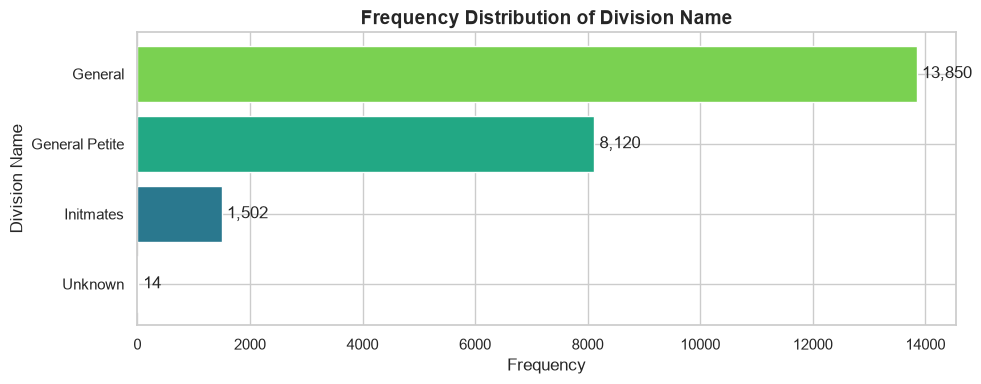

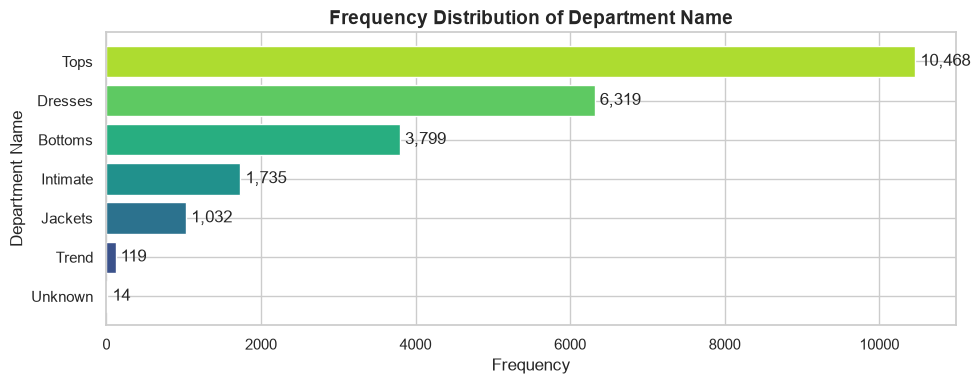

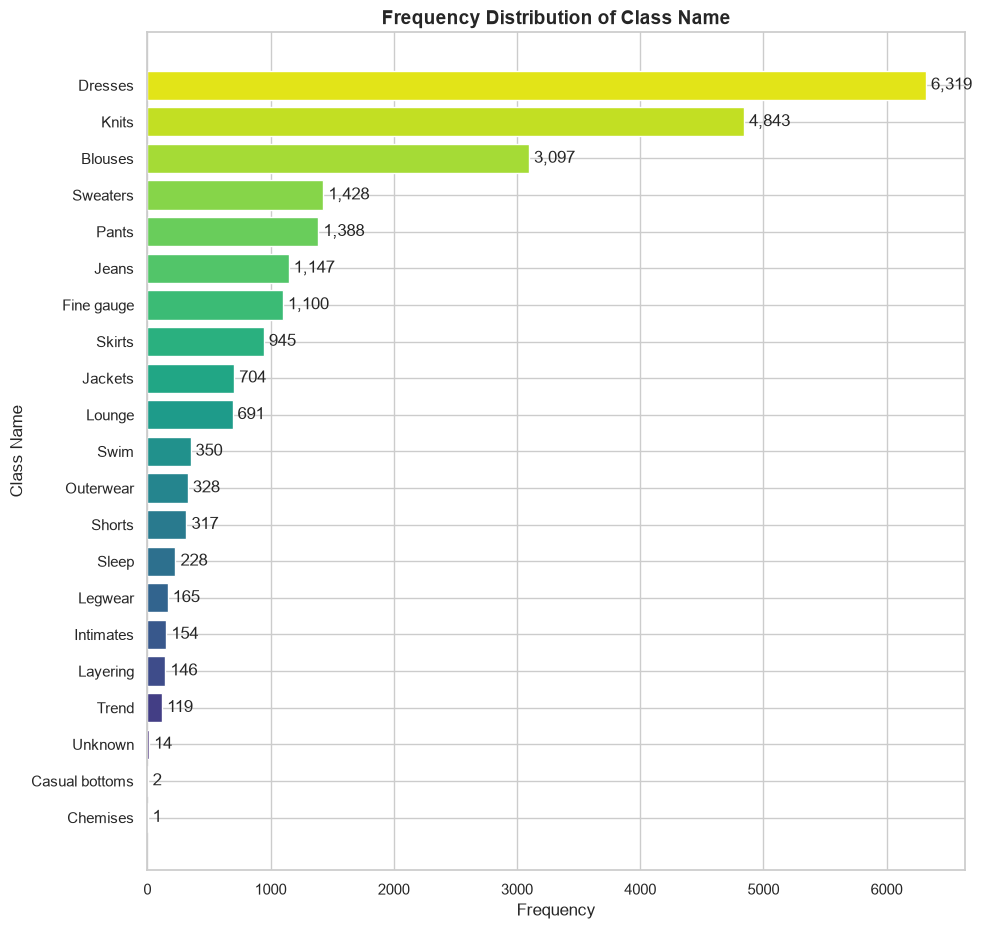

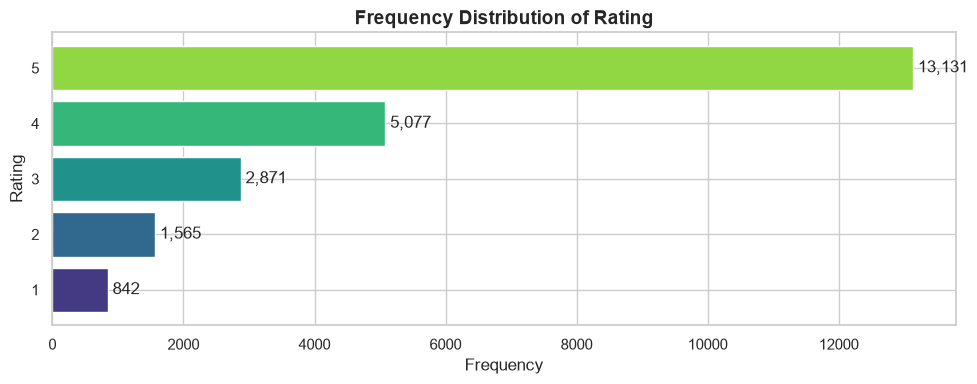

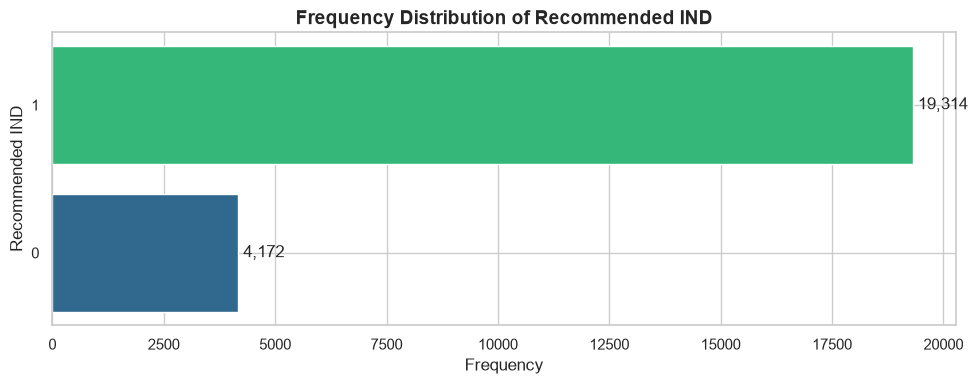

In [24]:
bar_chart_columns = [
    "Division Name",
    "Department Name",
    "Class Name",
    "Rating",
    "Recommended IND"
]

for column in bar_chart_columns:
    plot_frequency_bar(
        data=df_cat_clean,
        column=column
    )

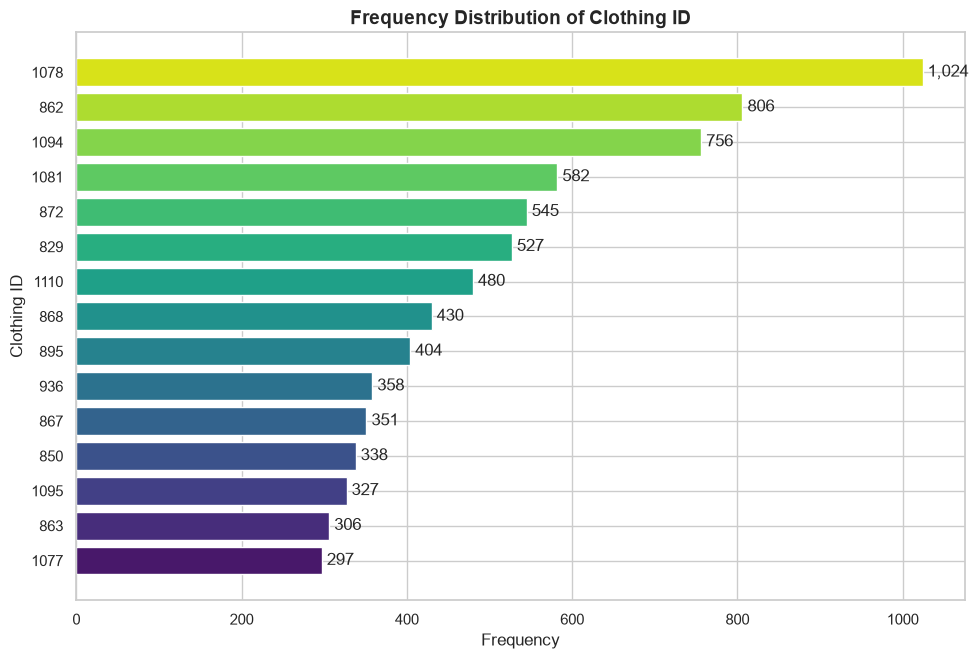

In [32]:
plot_frequency_bar(
    data=df_cat_clean,
    column="Clothing ID",
    top_n=15
)

In [33]:
def plot_category_pie(data, column, max_categories=10):
    unique_count = data[column].nunique()

    if unique_count > max_categories:
        print(
            f"{column} pie chart skipped: "
            f"{unique_count} categories are too many."
        )
        return

    category_counts = data[column].value_counts()

    plt.figure(figsize=(8, 7))

    plt.pie(
        category_counts.values,
        labels=category_counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        colors=sns.color_palette(
            "Set2",
            len(category_counts)
        ),
        wedgeprops={
            "edgecolor": "white",
            "linewidth": 1
        }
    )

    plt.title(
        f"Percentage Distribution of {column}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

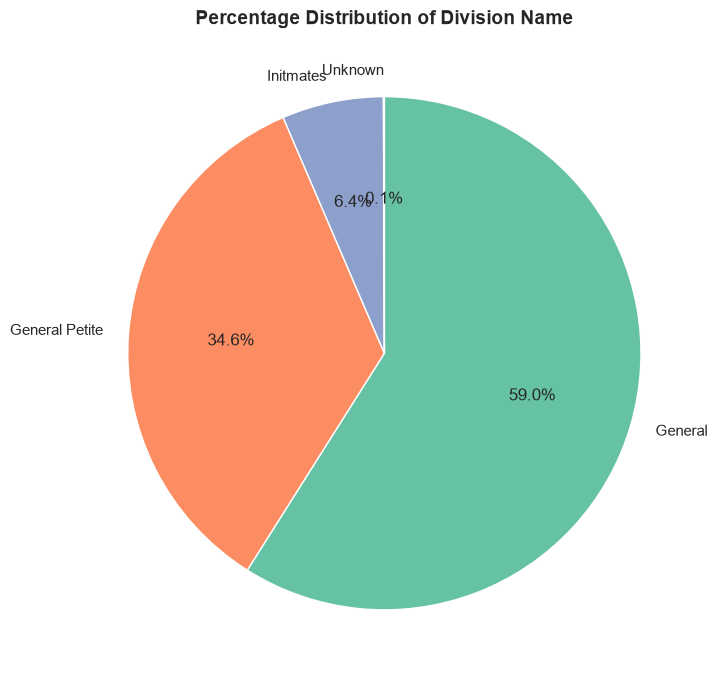

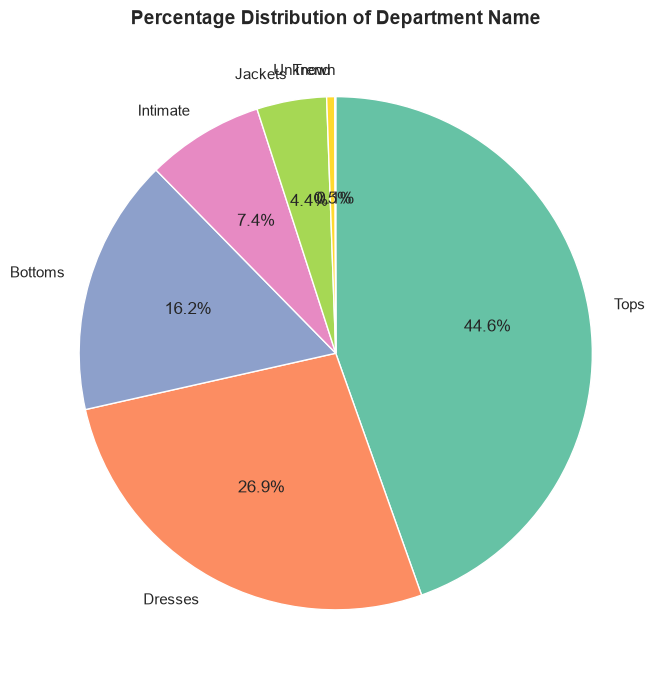

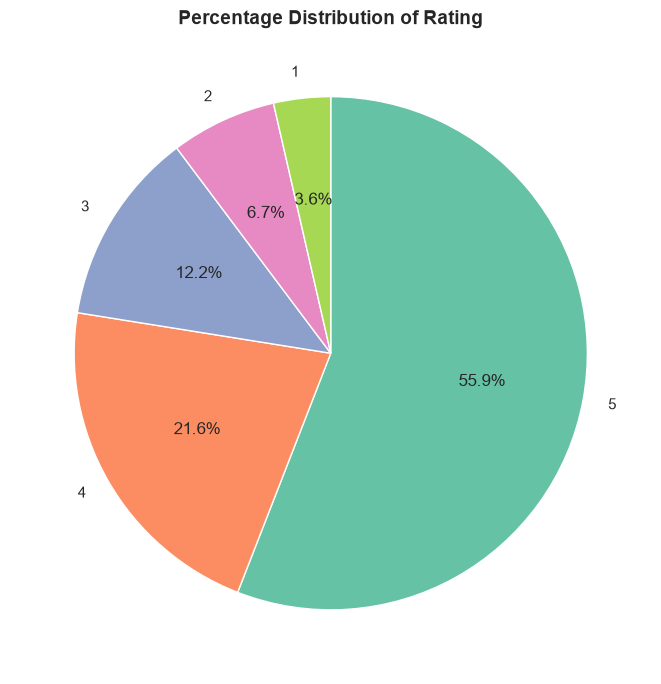

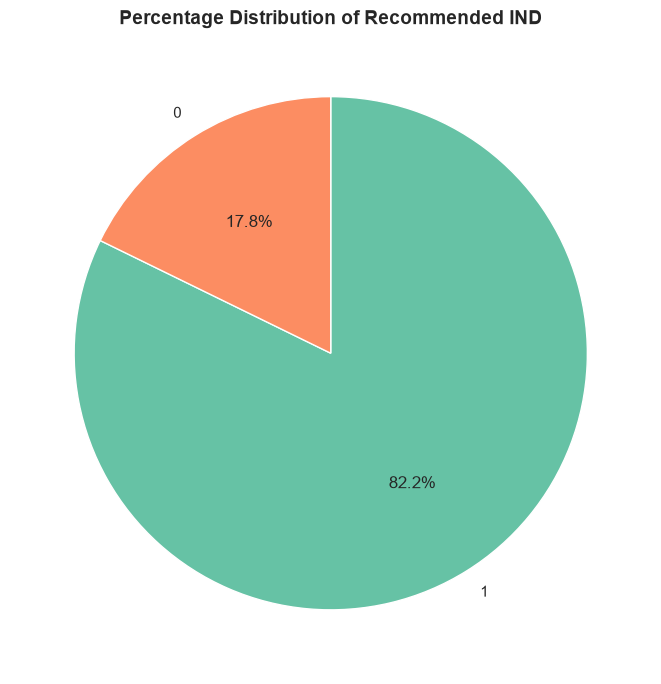

In [34]:
pie_chart_columns = [
    "Division Name",
    "Department Name",
    "Rating",
    "Recommended IND"
]

for column in pie_chart_columns:
    plot_category_pie(
        data=df_cat_clean,
        column=column,
        max_categories=10
    )

In [35]:
plot_category_pie(
    data=df_cat_clean,
    column="Class Name",
    max_categories=10
)

plot_category_pie(
    data=df_cat_clean,
    column="Clothing ID",
    max_categories=10
)

Class Name pie chart skipped: 21 categories are too many.
Clothing ID pie chart skipped: 1206 categories are too many.


In [39]:
def plot_stacked_recommendation(
    data,
    category_column,
    target_column="Recommended IND"
):

    category_order = (
        data[category_column]
        .value_counts()
        .index
    )

    stacked_data = pd.crosstab(
        data[category_column],
        data[target_column],
        normalize="index"
    ).mul(100)

    stacked_data = stacked_data.reindex(category_order)

    stacked_data = stacked_data.rename(
        columns={
            0: "Not Recommended",
            1: "Recommended"
        }
    )

    ax = stacked_data.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6),
        color=["#E76F51", "#2A9D8F"],
        edgecolor="white"
    )

    plt.title(
        f"{category_column} vs Recommendation Status",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel(category_column)
    plt.ylabel("Percentage of Reviews")
    plt.xticks(rotation=45, ha="right")
    plt.legend(
        title="Recommendation",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.ylim(0, 100)

    for container in ax.containers:
        labels = [
            f"{value:.1f}%" if value >= 4 else ""
            for value in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=8,
            color="white",
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

    return stacked_data.round(2)

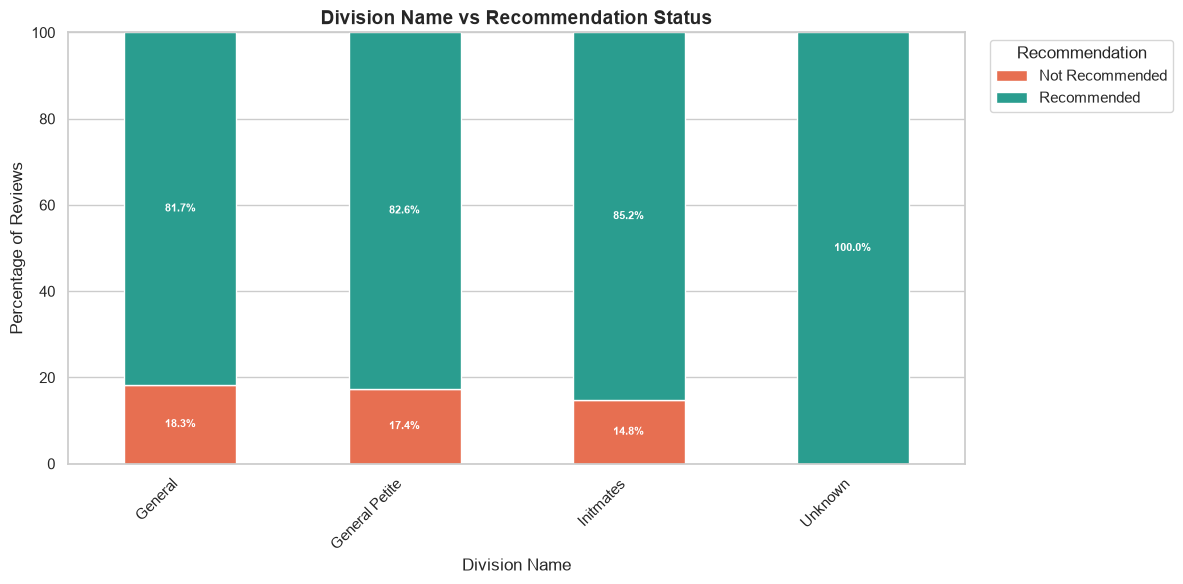

Recommended IND,Not Recommended,Recommended
Division Name,,
General,18.32,81.68
General Petite,17.40,82.60
Initmates,14.78,85.22
Unknown,0.00,100.00


In [40]:
division_stacked_table = plot_stacked_recommendation(
    data=df_cat_clean,
    category_column="Division Name"
)

display(division_stacked_table)

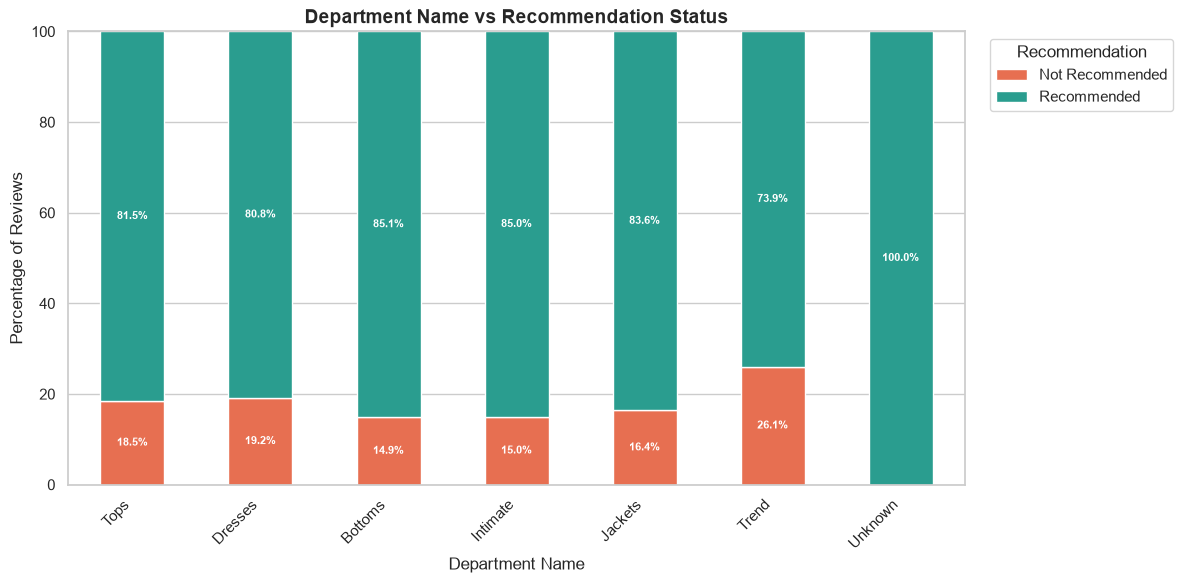

Recommended IND,Not Recommended,Recommended
Department Name,,
Tops,18.48,81.52
Dresses,19.18,80.82
Bottoms,14.87,85.13
Intimate,14.99,85.01
Jackets,16.38,83.62
Trend,26.05,73.95
Unknown,0.00,100.00


In [41]:
department_stacked_table = plot_stacked_recommendation(
    data=df_cat_clean,
    category_column="Department Name"
)

display(department_stacked_table)

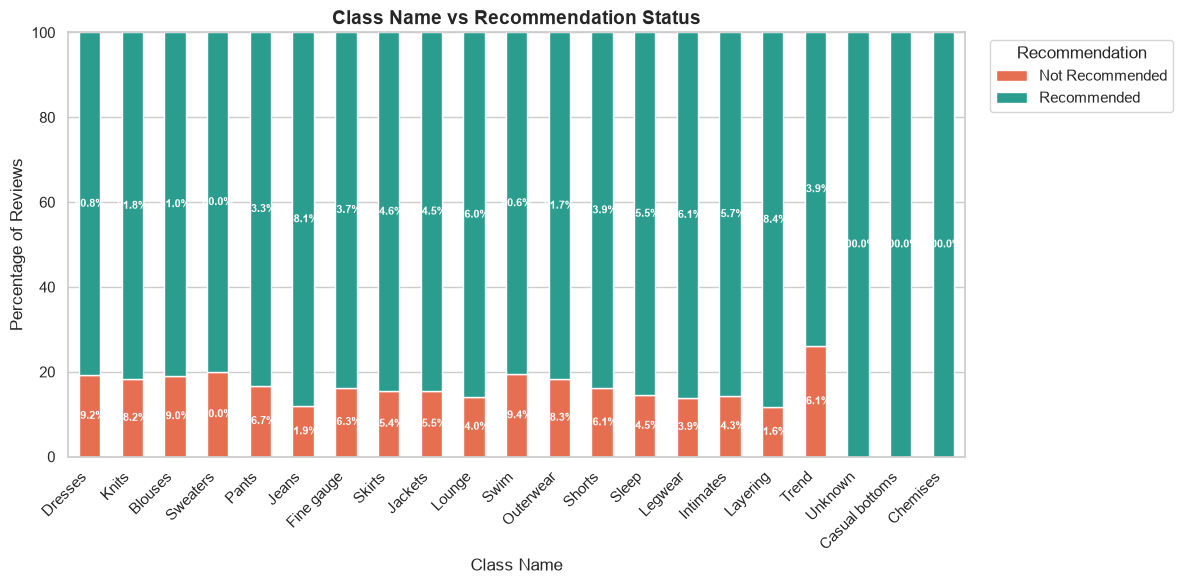

Recommended IND,Not Recommended,Recommended
Class Name,,
Dresses,19.18,80.82
Knits,18.23,81.77
Blouses,18.99,81.01
Sweaters,19.96,80.04
Pants,16.71,83.29
Jeans,11.86,88.14
Fine gauge,16.27,83.73
Skirts,15.45,84.55
Jackets,15.48,84.52


In [42]:
class_stacked_table = plot_stacked_recommendation(
    data=df_cat_clean,
    category_column="Class Name"
)

display(class_stacked_table)

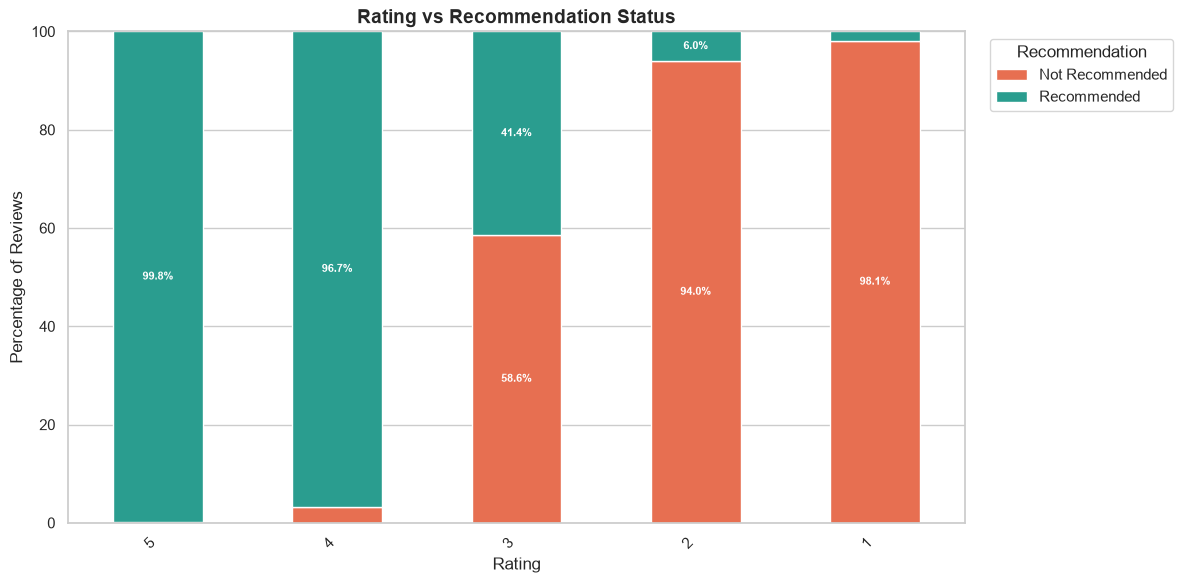

Recommended IND,Not Recommended,Recommended
Rating,,
5,0.19,99.81
4,3.31,96.69
3,58.59,41.41
2,93.99,6.01
1,98.10,1.90


In [43]:
rating_stacked_table = plot_stacked_recommendation(
    data=df_cat_clean,
    category_column="Rating"
)

display(rating_stacked_table)

In [47]:
def calculate_category_entropy(data, column):

    category_counts = data[column].value_counts(
        dropna=False
    )

    counts_array = category_counts.to_numpy(
        dtype=np.float64
    )

    probabilities = (
        counts_array / counts_array.sum()
    )

    category_count = len(probabilities)

    entropy = -float(
        np.sum(
            probabilities * np.log2(probabilities)
        )
    )

    max_entropy = (
        float(np.log2(category_count))
        if category_count > 1 else 0.0
    )

    normalized_entropy = (
        entropy / max_entropy
        if max_entropy > 0 else 0.0
    )

    dominant_percentage = (
        float(probabilities.max() * 100)
        if category_count > 0 else 0.0
    )

    effective_categories = float(2 ** entropy)

    return {
        "Column": column,
        "Category_Count": category_count,
        "Entropy": round(entropy, 4),
        "Maximum_Entropy": round(max_entropy, 4),
        "Normalized_Entropy": round(
            normalized_entropy,
            4
        ),
        "Importance_Score": round(
            normalized_entropy * 100,
            2
        ),
        "Dominant_Category_Percentage": round(
            dominant_percentage,
            2
        ),
        "Effective_Categories": round(
            effective_categories,
            2
        )
    }

In [48]:
entropy_records = []

for column in analysis_columns:
    result = calculate_category_entropy(
        df_cat_clean,
        column
    )
    entropy_records.append(result)

entropy_summary = pd.DataFrame(entropy_records)

entropy_summary = entropy_summary.sort_values(
    by="Importance_Score",
    ascending=False
).reset_index(drop=True)

entropy_summary.insert(
    0,
    "Importance_Rank",
    range(1, len(entropy_summary) + 1)
)

display(entropy_summary)

,Importance_Rank,Column,Category_Count,Entropy,Maximum_Entropy,Normalized_Entropy,Importance_Score,Dominant_Category_Percentage,Effective_Categories
0,1,Rating,5,1.7499,2.3219,0.7536,75.36,55.91,3.36
1,2,Class Name,21,3.2743,4.3923,0.7455,74.55,26.91,9.68
2,3,Clothing ID,1206,7.6141,10.2360,0.7439,74.39,4.36,195.91
3,4,Department Name,7,1.9751,2.8074,0.7036,70.36,44.57,3.93
4,5,Recommended IND,2,0.6749,1.0000,0.6749,67.49,82.24,1.60
5,6,Division Name,4,1.2391,2.0000,0.6196,61.96,58.97,2.36


In [49]:
def interpret_entropy(score):
    if score >= 80:
        return "Very High Diversity"
    elif score >= 60:
        return "High Diversity"
    elif score >= 40:
        return "Moderate Diversity"
    elif score >= 20:
        return "Low Diversity"
    else:
        return "Very Low Diversity"

entropy_summary["Interpretation"] = (
    entropy_summary["Importance_Score"]
    .apply(interpret_entropy)
)

display(
    entropy_summary[
        [
            "Importance_Rank",
            "Column",
            "Category_Count",
            "Importance_Score",
            "Dominant_Category_Percentage",
            "Interpretation"
        ]
    ]
)

,Importance_Rank,Column,Category_Count,Importance_Score,Dominant_Category_Percentage,Interpretation
0,1,Rating,5,75.36,55.91,High Diversity
1,2,Class Name,21,74.55,26.91,High Diversity
2,3,Clothing ID,1206,74.39,4.36,High Diversity
3,4,Department Name,7,70.36,44.57,High Diversity
4,5,Recommended IND,2,67.49,82.24,High Diversity
5,6,Division Name,4,61.96,58.97,High Diversity


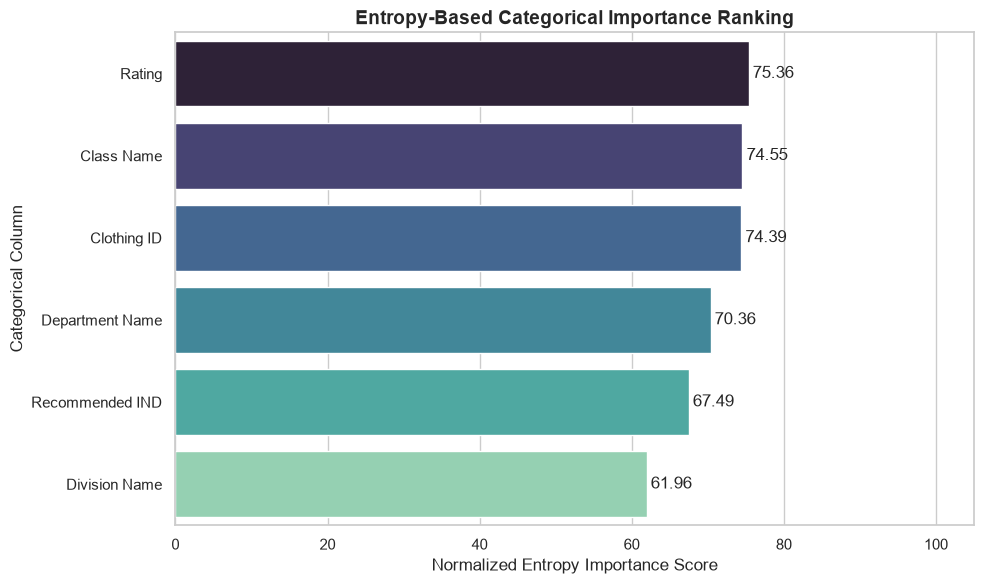

In [50]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=entropy_summary,
    x="Importance_Score",
    y="Column",
    hue="Column",
    palette="mako",
    legend=False
)

plt.title(
    "Entropy-Based Categorical Importance Ranking",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Normalized Entropy Importance Score")
plt.ylabel("Categorical Column")
plt.xlim(0, 105)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [51]:
validation_summary = pd.DataFrame({
    "Check": [
        "Original rows",
        "Cleaned categorical rows",
        "Encoded rows",
        "Selected categorical columns",
        "Missing values after cleaning",
        "Encoded missing values",
        "Frequency tables created",
        "Entropy columns analysed"
    ],
    "Result": [
        len(df),
        len(df_cat_clean),
        len(encoded_categorical_data),
        len(analysis_columns),
        int(df_cat_clean.isnull().sum().sum()),
        int(encoded_categorical_data.isnull().sum().sum()),
        len(frequency_tables),
        len(entropy_summary)
    ]
})

display(validation_summary)

,Check,Result
0,Original rows,23486
1,Cleaned categorical rows,23486
2,Encoded rows,23486
3,Selected categorical columns,6
4,Missing values after cleaning,0
5,Encoded missing values,0
6,Frequency tables created,6
7,Entropy columns analysed,6


In [52]:
final_encoded_dataset = pd.concat(
    [
        df_work[["no"]].reset_index(drop=True),
        encoded_categorical_data.reset_index(drop=True)
    ],
    axis=1
)

print(
    "Final encoded dataset shape:",
    final_encoded_dataset.shape
)

display(final_encoded_dataset.head())

Final encoded dataset shape: (23486, 34)


,no,Division Name_General,Division Name_General Petite,Division Name_Initmates,Division Name_Unknown,Department Name_Bottoms,Department Name_Dresses,Department Name_Intimate,Department Name_Jackets,Department Name_Tops,...,Class Name_Sweaters,Class Name_Swim,Rating_1,Rating_2,Rating_3,Rating_4,Rating_5,Recommended IND_0,Recommended IND_1,Clothing ID_Frequency
0,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0.000085
1,1,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0.012305
2,2,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0.012646
3,3,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0.001363
4,4,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0.000170


In [53]:
division_stacked_table.to_csv(
    "division_recommendation_distribution.csv"
)

department_stacked_table.to_csv(
    "department_recommendation_distribution.csv"
)

class_stacked_table.to_csv(
    "class_recommendation_distribution.csv"
)

rating_stacked_table.to_csv(
    "rating_recommendation_distribution.csv"
)

print("Stacked-bar tables saved successfully.")

Stacked-bar tables saved successfully.


In [54]:
df_cat_clean.to_csv(
    "cleaned_categorical_data.csv",
    index=False
)

cardinality_summary.to_csv(
    "categorical_cardinality_summary.csv",
    index=False
)

all_frequency_distributions.to_csv(
    "categorical_frequency_distributions.csv",
    index=False
)

encoding_report.to_csv(
    "categorical_encoding_report.csv",
    index=False
)

entropy_summary.to_csv(
    "categorical_entropy_summary.csv",
    index=False
)

final_encoded_dataset.to_csv(
    "encoded_categorical_dataset.csv",
    index=False
)

validation_summary.to_csv(
    "categorical_analysis_validation.csv",
    index=False
)

print("All project files saved successfully!")

All project files saved successfully!


In [55]:
output_files = [
    "cleaned_categorical_data.csv",
    "categorical_cardinality_summary.csv",
    "categorical_frequency_distributions.csv",
    "categorical_encoding_report.csv",
    "categorical_entropy_summary.csv",
    "encoded_categorical_dataset.csv",
    "categorical_analysis_validation.csv",
    "division_recommendation_distribution.csv",
    "department_recommendation_distribution.csv",
    "class_recommendation_distribution.csv",
    "rating_recommendation_distribution.csv"
]

file_verification = pd.DataFrame({
    "File_Name": output_files,
    "Successfully_Saved": [
        os.path.exists(file)
        for file in output_files
    ]
})

display(file_verification)

,File_Name,Successfully_Saved
0,cleaned_categorical_data.csv,True
1,categorical_cardinality_summary.csv,True
2,categorical_frequency_distributions.csv,True
3,categorical_encoding_report.csv,True
4,categorical_entropy_summary.csv,True
5,encoded_categorical_dataset.csv,True
6,categorical_analysis_validation.csv,True
7,division_recommendation_distribution.csv,True
8,department_recommendation_distribution.csv,True
9,class_recommendation_distribution.csv,True
